In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import networkx as nx
import warnings
from sklearn.pipeline import Pipeline # Import Pipeline
warnings.filterwarnings('ignore')

In [ ]:
# STAGE 1: DATA LOADING
def load_data(filepath):
    print("--- Stage 1: Data Loading ---")
    # Load gene expression dataset using pandas
    try:
        df = pd.read_excel("/content/GSE6283_gene_expression.xlsx")
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None, None

    df = df.set_index('ID_REF').T  # Transpose: rows = samples, columns = genes (features)

    # Separate features and labels (normal vs trisomy)
    # The dataset has 21 samples.
    # Assuming first 10 are Normal, remaining 11 are Trisomy.
    labels = ['Normal'] * 10 + ['Trisomy'] * 11
    df['Label'] = labels

    features = df.drop(columns=['Label'])
    labels = df['Label']
    print(f"Features shape: {features.shape}, Labels shape: {labels.shape}")
    return features, labels

In [ ]:
features, labels = load_data("/content/GSE6283_gene_expression.xlsx")

--- Stage 1: Data Loading ---
Features shape: (21, 54676), Labels shape: (21,)


In [ ]:
# STAGE 2: PREPROCESSING
def preprocess_data(features):
    print("\n--- Stage 2: Preprocessing ---")
    features = features.astype(float) # Ensure float type

    # Handle missing values by filling with column means
    features = features.fillna(features.mean())

    # Apply Log2 transformation (adding 1 to avoid taking log of 0 or negligible values)
    features_log = np.log2(features.clip(lower=0) + 1)

    # Normalize data using StandardScaler (Z-score normalization)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_log)
    features_scaled = pd.DataFrame(features_scaled, columns=features.columns, index=features.index)

    print("Preprocessing complete: Nulls handled, Log2 transformed, Z-score normalized.")
    return features_scaled
features_scaled = preprocess_data(features)


--- Stage 2: Preprocessing ---
Preprocessing complete: Nulls handled, Log2 transformed, Z-score normalized.



--- Stage 3: Exploratory Data Analysis ---
Displaying EDA plots...


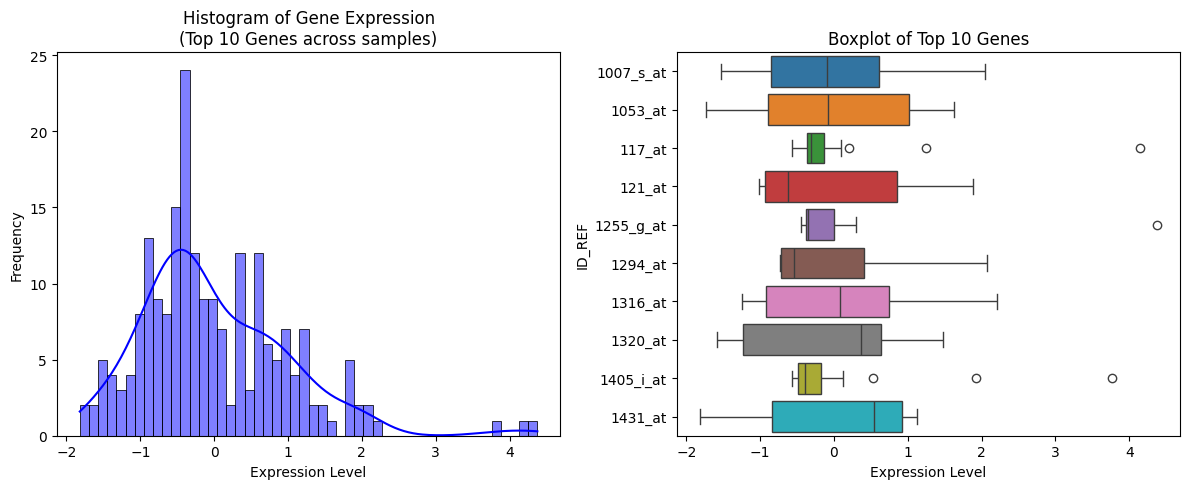

In [ ]:
# STAGE 3: EXPLORATORY DATA ANALYSIS
def exploratory_data_analysis(features):
    print("\n--- Stage 3: Exploratory Data Analysis ---")
    # Plot histogram and boxplot for a subset of random genes to avoid clutter
    subset_genes = features.iloc[:, :10] # Take first 10 genes for visualization

    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(subset_genes.values.flatten(), bins=50, kde=True, color='blue')
    plt.title("Histogram of Gene Expression\n(Top 10 Genes across samples)")
    plt.xlabel("Expression Level")
    plt.ylabel("Frequency")

    # Boxplot to detect outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(data=subset_genes, orient='h')
    plt.title("Boxplot of Top 10 Genes")
    plt.xlabel("Expression Level")

    plt.tight_layout()
    print("Displaying EDA plots...")
    plt.show()
exploratory_data_analysis(features_scaled)

In [ ]:
# STAGE 4: DIFFERENTIAL GENE EXPRESSION
def differential_expression(features, labels):
    print("\n--- Stage 4: Differential Gene Expression ---")

    # Split samples into two groups
    group_normal = features[labels == 'Normal']
    group_trisomy = features[labels == 'Trisomy']

    # Perform two-sample t-test for each gene (vectorized)
    stat, p_values = stats.ttest_ind(group_normal, group_trisomy, equal_var=False, axis=0)

    # Calculate Log Fold Change (mean(Trisomy) - mean(Normal))
    log_fc = group_trisomy.mean(axis=0) - group_normal.mean(axis=0)

    # Multiple testing correction (Benjamini-Hochberg)
    sorted_indices = np.argsort(p_values)
    n = len(p_values)
    fdr_adjusted_p = np.zeros(n)
    for i, rank in enumerate(range(1, n+1)):
        fdr_adjusted_p[sorted_indices[i]] = p_values[sorted_indices[i]] * n / rank

    # Cap p-values at 1.0
    fdr_adjusted_p = np.minimum(fdr_adjusted_p, 1.0)

    # Store results
    results = pd.DataFrame({
        'Gene': features.columns,
        'p_value': p_values,
        'adj_p_value': fdr_adjusted_p,
        'log_fc': log_fc
    }).set_index('Gene')

    # Filter genes with p-value < 0.05
    significant_genes = results[results['p_value'] < 0.05]
    print(f"Total significant genes (p < 0.05): {len(significant_genes)}")
    return results, significant_genes
results, significant_genes = differential_expression(features_scaled, labels)


--- Stage 4: Differential Gene Expression ---
Total significant genes (p < 0.05): 5342


In [ ]:
# STAGE 5: FEATURE SELECTION
def feature_selection(features, significant_genes, top_n=200):
    print("\n--- Stage 5: Feature Selection ---")
    # Select top 100-500 significant genes based on lowest p-value
    top_genes_df = significant_genes.sort_values(by='p_value').head(top_n)
    selected_genes = top_genes_df.index.tolist()

    print(f"Selected Top {len(selected_genes)} significant genes.")
    print("Top 5 Differentially Expressed Genes:")
    print(top_genes_df.head(5))
    return features[selected_genes], top_genes_df
selected_features, top_genes_df = feature_selection(features_scaled, significant_genes)


--- Stage 5: Feature Selection ---
Selected Top 200 significant genes.
Top 5 Differentially Expressed Genes:
              p_value  adj_p_value    log_fc
Gene                                        
211709_s_at  0.000016     0.877749 -1.602302
224443_at    0.000025     0.684327 -1.568468
238574_at    0.000028     0.508902 -1.574178
206091_at    0.000057     0.785133 -1.523164
209465_x_at  0.000076     0.829288 -1.545505



--- Stage 6: Network Analysis ---
Graph initialized with 50 nodes and 179 edges.
Top 5 Hub Genes (Degree Centrality): [('1556064_at', 0.44897959183673464), ('209466_x_at', 0.4081632653061224), ('208950_s_at', 0.4081632653061224), ('62212_at', 0.3877551020408163), ('211709_s_at', 0.36734693877551017)]
Detected 14 modularity-based communities.
Displaying Network graph...


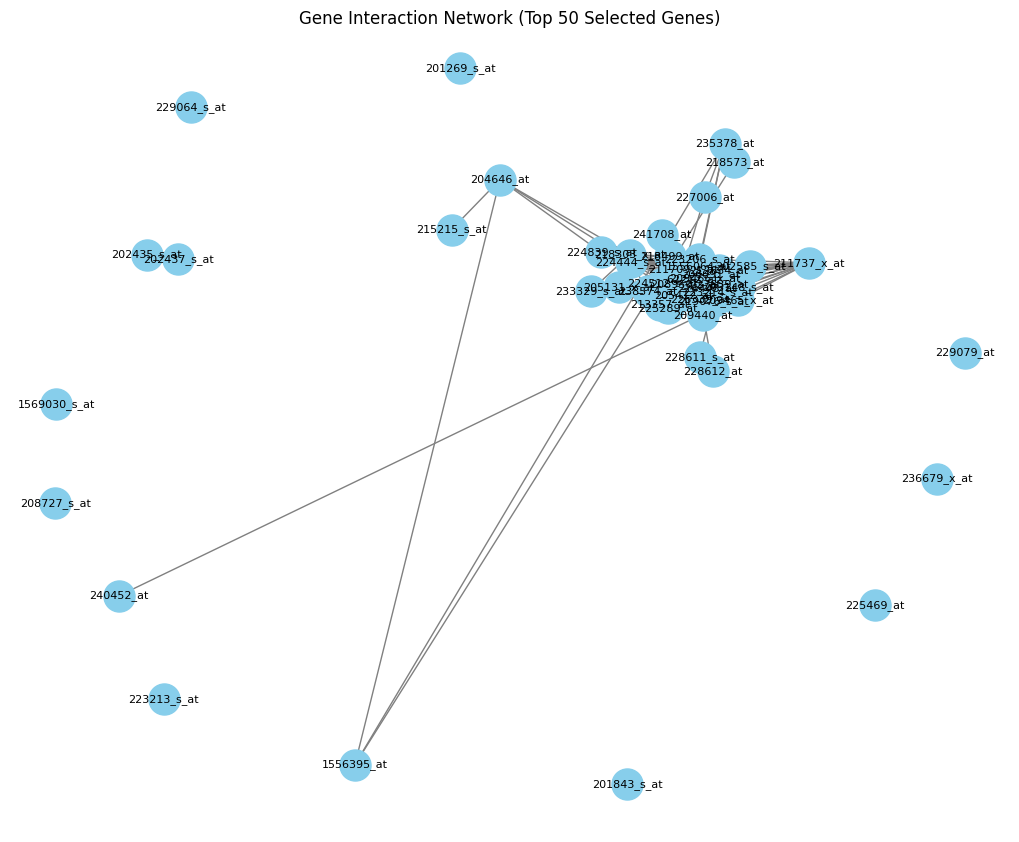

In [ ]:
# STAGE 6: NETWORK ANALYSIS
def network_analysis(selected_features):
    print("\n--- Stage 6: Network Analysis ---")

    # Due to plotting limitations, let's limit network to top 50 features
    subset_features = selected_features.iloc[:, :50]

    # Correlation matrix as edge weights
    corr_matrix = subset_features.corr(method='pearson')

    # Create Graph
    G = nx.Graph()
    genes = corr_matrix.columns
    G.add_nodes_from(genes)

    # Add edges for correlation > 0.8
    threshold = 0.8
    for i in range(len(genes)):
        for j in range(i+1, len(genes)):
            weight = corr_matrix.iloc[i, j]
            if abs(weight) > threshold:
                G.add_edge(genes[i], genes[j], weight=weight)

    print(f"Graph initialized with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

    # Compute Centralities
    degree_cent = nx.degree_centrality(G)
    betweenness_cent = nx.betweenness_centrality(G)

    # Top Hub Genes
    hub_genes = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
    print("Top 5 Hub Genes (Degree Centrality):", hub_genes)

    # Community detection
    try:
        from networkx.algorithms.community import greedy_modularity_communities
        communities = greedy_modularity_communities(G)
        print(f"Detected {len(communities)} modularity-based communities.")
    except Exception as e:
        print("Community detection issue:", e)

    # Visualize Network
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=500, node_color='skyblue', font_size=8, edge_color='gray')
    plt.title("Gene Interaction Network (Top 50 Selected Genes)")
    print("Displaying Network graph...")
    plt.show()
network_analysis(selected_features)

In [ ]:
# STAGE 7 & 8: MACHINE LEARNING + CROSS VALIDATION
def train_and_cross_validate_models(X_train, y_train):
    print("\n--- Stage 7 & 8: Machine Learning & Cross Validation ---")

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'SVM': SVC(kernel='linear', probability=True),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
    }

    trained_models = {}

    for name, model in models.items():
        print(f"\n{name}:")

        # Use Pipeline to avoid data leakage
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        # Stratified K-Fold
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Cross-validation
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')

        print(f"5-Fold CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

        # Train final model on full training data
        pipeline.fit(X_train, y_train)
        trained_models[name] = pipeline

    return trained_models
trained_models = train_and_cross_validate_models(X_train, y_train)


--- Stage 7 & 8: Machine Learning & Cross Validation ---

Logistic Regression:
5-Fold CV Accuracy: 0.9333 (+/- 0.1333)

SVM:
5-Fold CV Accuracy: 1.0000 (+/- 0.0000)

Random Forest:
5-Fold CV Accuracy: 0.8000 (+/- 0.2667)


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(selected_features, labels, test_size=0.3, random_state=42, stratify=labels)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (14, 200)
y_train shape: (14,)
X_test shape: (7, 200)
y_test shape: (7,)


In [ ]:
# STAGE 9: MODEL EVALUATION
def evaluate_models(trained_models, X_test, y_test):
    print("\n--- Stage 9: Model Evaluation ---")

    for name, model in trained_models.items():
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label='Trisomy')
        rec = recall_score(y_test, y_pred, pos_label='Trisomy')
        f1 = f1_score(y_test, y_pred, pos_label='Trisomy')

        print(f"\nModel: {name}")
        print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
evaluate_models(trained_models, X_test, y_test)



--- Stage 9: Model Evaluation ---

Model: Logistic Regression
Accuracy: 0.8571, Precision: 0.8000, Recall: 1.0000, F1-score: 0.8889
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.67      0.80         3
     Trisomy       0.80      1.00      0.89         4

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7


Model: SVM
Accuracy: 0.8571, Precision: 0.8000, Recall: 1.0000, F1-score: 0.8889
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.67      0.80         3
     Trisomy       0.80      1.00      0.89         4

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7


Model: Random Forest
Accuracy: 0.8571, Precision: 0.8000, Recall: 1.0000, F1-score: 


--- Stage 10: PCA ---
Displaying PCA plot...


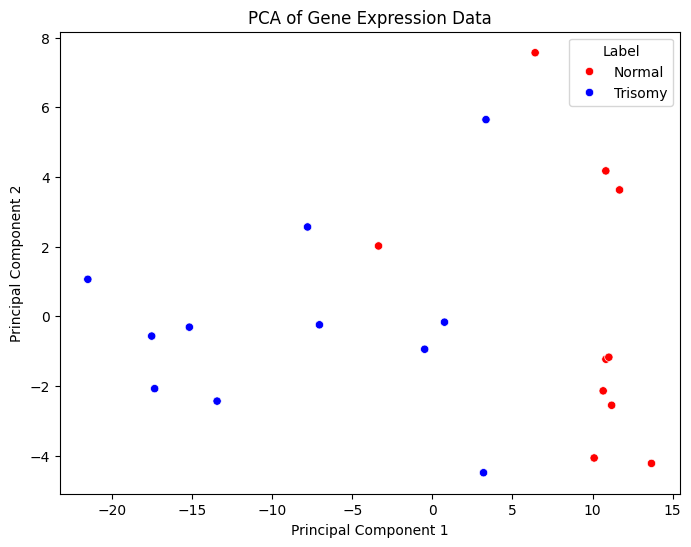

In [ ]:
# STAGE 10: PCA
def apply_pca(features, labels):
    print("\n--- Stage 10: PCA ---")

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(features)

    pca_df = pd.DataFrame(data=pca_result, columns=['Principal Component 1', 'Principal Component 2'])
    pca_df['Label'] = labels.values

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Label', data=pca_df, palette=['red', 'blue'])
    plt.title("PCA of Gene Expression Data")
    print("Displaying PCA plot...")
    plt.show()
apply_pca(selected_features, labels)



--- Stage 11: Clustering ---
Displaying Dendrogram...


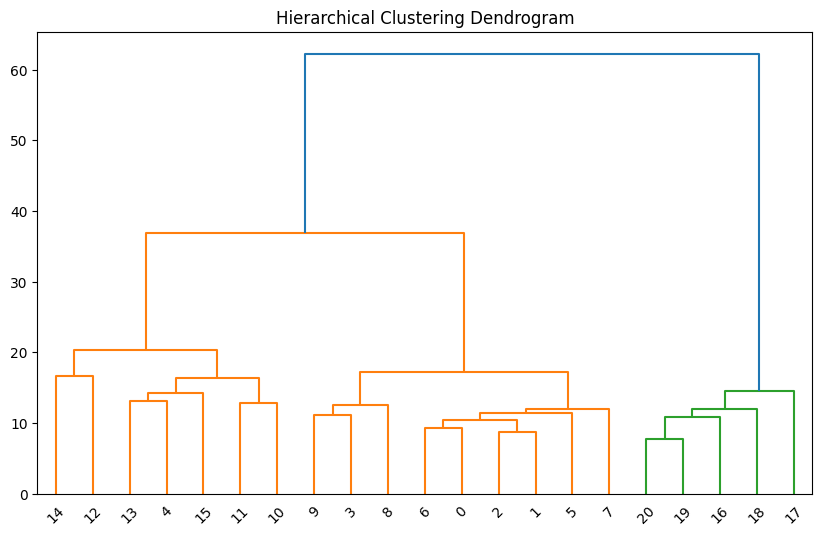

K-Means Clustering applied (K=2).
Displaying K-Means plot...


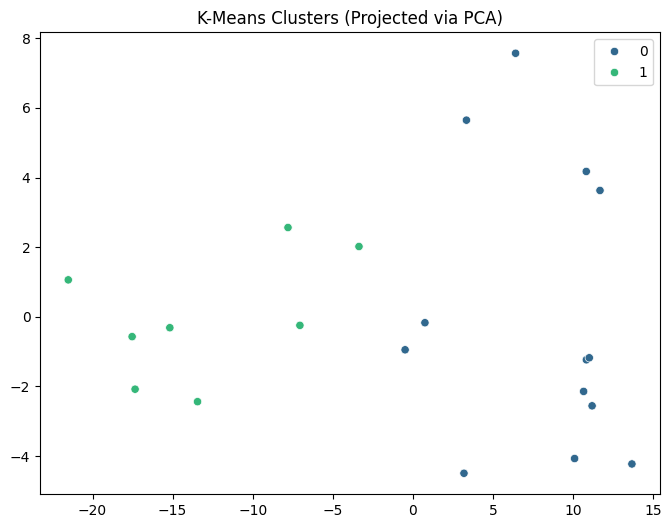

In [ ]:
# STAGE 11: CLUSTERING
def apply_clustering(features):
    print("\n--- Stage 11: Clustering ---")

    # Hierarchical Clustering (Dendrogram)
    linked = linkage(features, method='ward')
    plt.figure(figsize=(10, 6))
    dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
    plt.title("Hierarchical Clustering Dendrogram")
    print("Displaying Dendrogram...")
    plt.show()

    # K-means Clustering
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans_labels = kmeans.fit_predict(features)
    print("K-Means Clustering applied (K=2).")

    # Plot K-means clusters on existing PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(features)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=kmeans_labels, palette='viridis')
    plt.title("K-Means Clusters (Projected via PCA)")
    print("Displaying K-Means plot...")
    plt.show()
apply_clustering(selected_features)

Starting Bioinformatics Analysis pipeline...

--- Stage 1: Data Loading ---
Features shape: (21, 54676), Labels shape: (21,)

--- Stage 2: Preprocessing ---
Preprocessing complete: Nulls handled, Log2 transformed, Z-score normalized.

--- Stage 3: Exploratory Data Analysis ---
Displaying EDA plots...


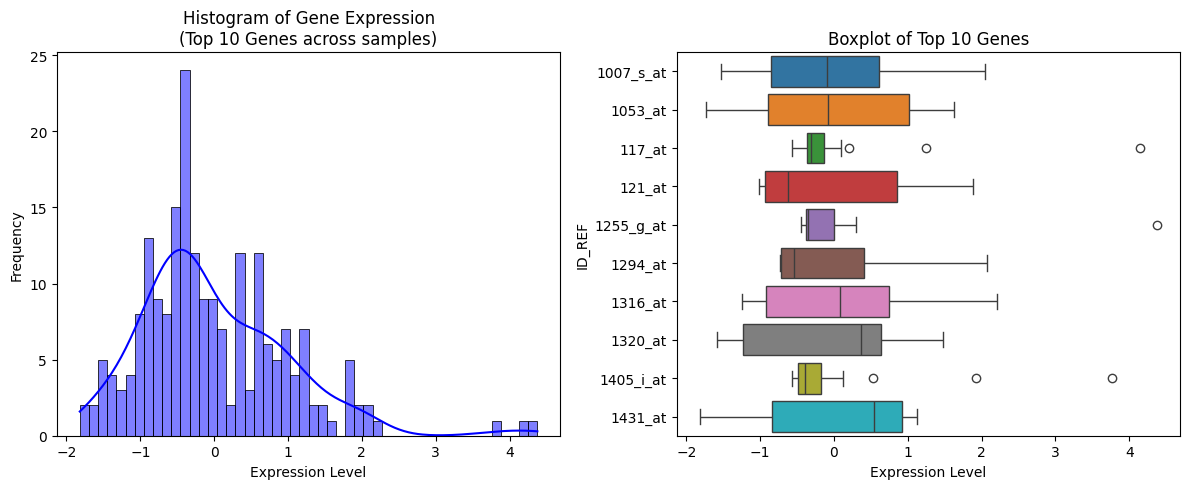


--- Stage 4: Differential Gene Expression ---
Total significant genes (p < 0.05): 5342

--- Stage 5: Feature Selection ---
Selected Top 200 significant genes.
Top 5 Differentially Expressed Genes:
              p_value  adj_p_value    log_fc
Gene                                        
211709_s_at  0.000016     0.877749 -1.602302
224443_at    0.000025     0.684327 -1.568468
238574_at    0.000028     0.508902 -1.574178
206091_at    0.000057     0.785133 -1.523164
209465_x_at  0.000076     0.829288 -1.545505

--- Stage 6: Network Analysis ---
Graph initialized with 50 nodes and 179 edges.
Top 5 Hub Genes (Degree Centrality): [('1556064_at', 0.44897959183673464), ('209466_x_at', 0.4081632653061224), ('208950_s_at', 0.4081632653061224), ('62212_at', 0.3877551020408163), ('211709_s_at', 0.36734693877551017)]
Detected 14 modularity-based communities.
Displaying Network graph...


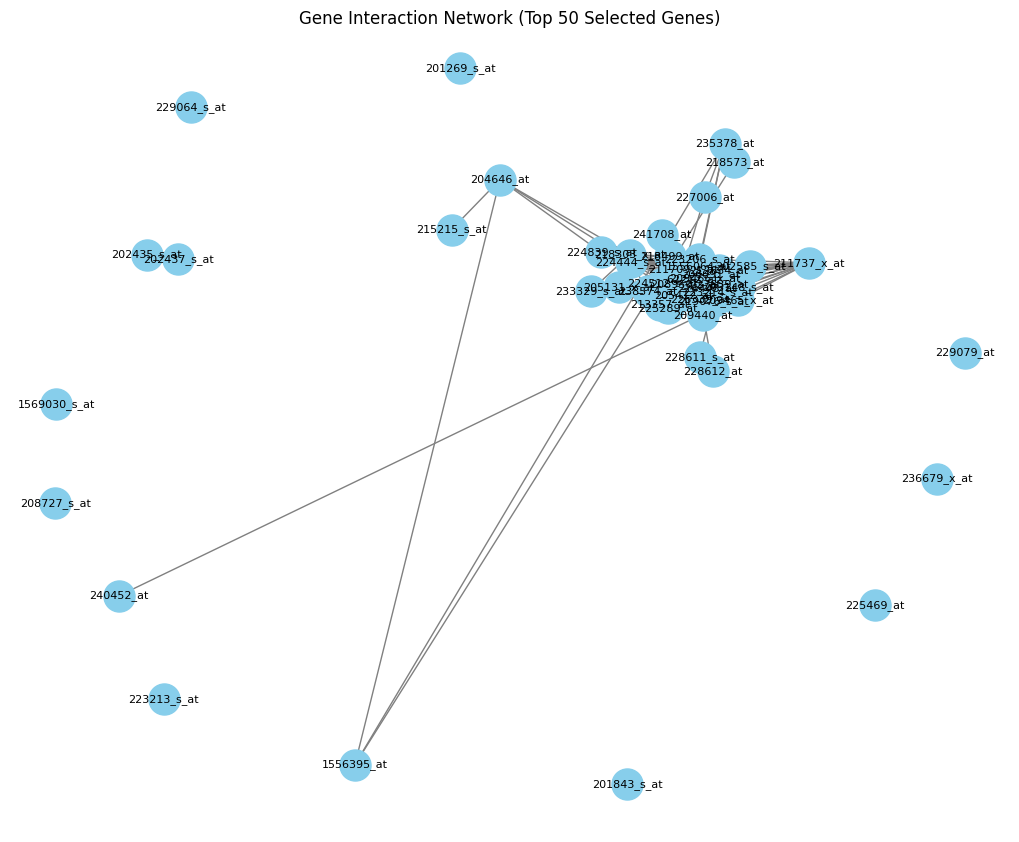


--- Stage 7 & 8: Machine Learning & Cross Validation ---

Logistic Regression:
5-Fold CV Accuracy: 0.8167 (+/- 0.1528)

SVM:
5-Fold CV Accuracy: 0.8167 (+/- 0.1528)

Random Forest:
5-Fold CV Accuracy: 0.7500 (+/- 0.1291)

--- Stage 9: Model Evaluation ---

Model: Logistic Regression
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         2
     Trisomy       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Model: SVM
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         2
     Trisomy       1.00      1.00      1.00         3

    accuracy              

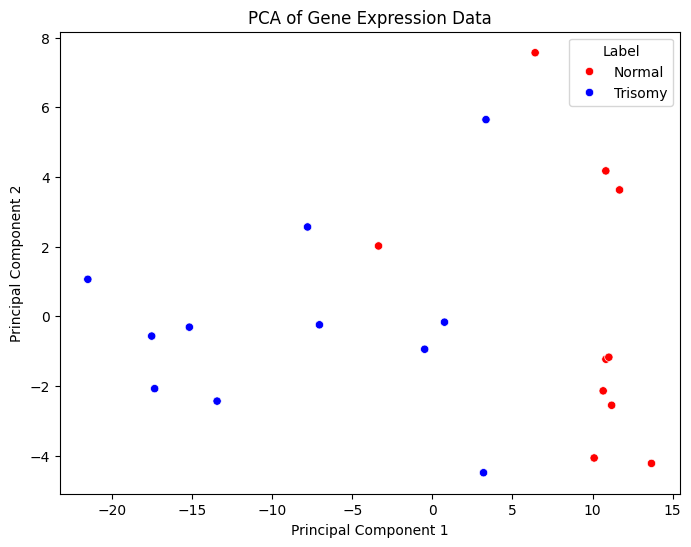


--- Stage 11: Clustering ---
Displaying Dendrogram...


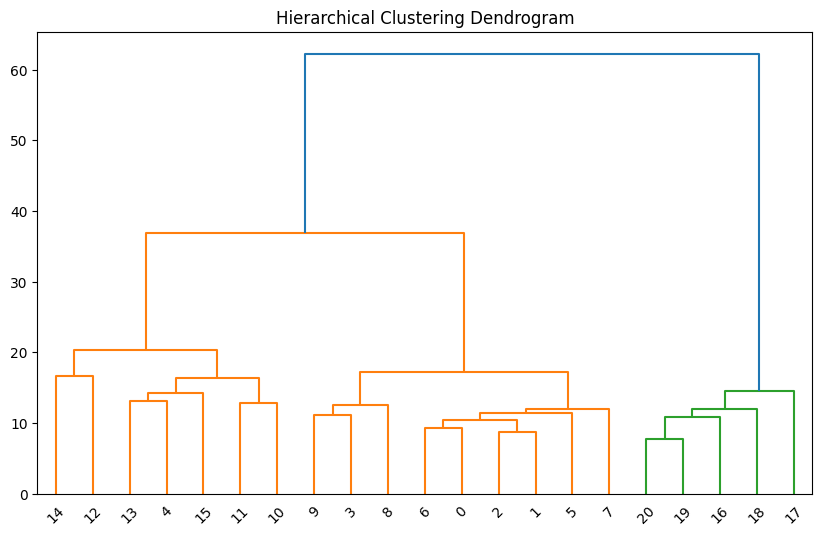

K-Means Clustering applied (K=2).
Displaying K-Means plot...


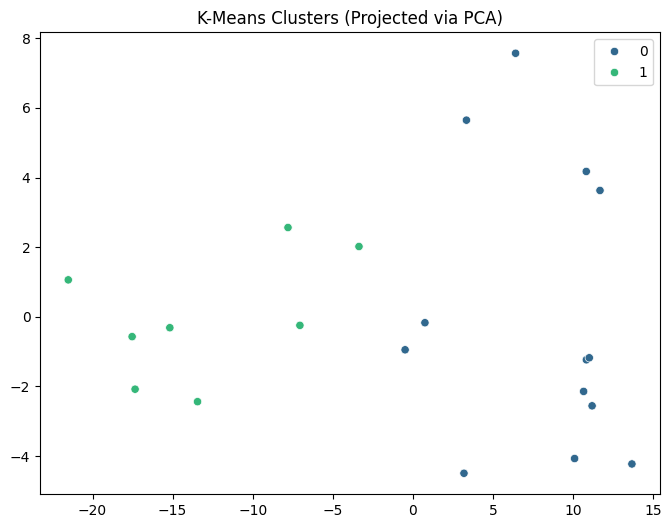


Pipeline finished successfully! Outputs were displayed directly.

[INFO] Generated 'new_patient_sample.csv' containing TRUE raw expression data of an Edwards Syndrome patient!

Do you want to analyze a new gene sample? (yes/no): yes
Enter the CSV file path for the new sample: new_sample.csv
Error: The file 'new_sample.csv' could not be found.

Do you want to analyze a new gene sample? (yes/no): yes
Enter the CSV file path for the new sample: /content/new_patient_sample.csv

=> Prediction: NORMAL
=> Explanation: The given expression profile indicates a normal euploid sample without Trisomy 18 characteristics.


Do you want to analyze a new gene sample? (yes/no): no


In [ ]:
# ========================
# USER PREDICTION MODULE
# ========================
def predict_new_sample(model, scaler, expected_columns):
    while True:
        choice = input("\nDo you want to analyze a new gene sample? (yes/no): ").strip().lower()
        if choice not in ['yes', 'y']:
            break

        filepath = input("Enter the CSV file path for the new sample: ").strip()

        try:
            # Load new sample
            new_df = pd.read_csv(filepath)

            # Check for column mismatch
            missing_cols = [col for col in expected_columns if col not in new_df.columns]
            if missing_cols:
                print(f"Error: The input CSV is missing {len(missing_cols)} required gene columns used during training.")
                print("Missing columns include:", missing_cols[:5], "...")
                continue

            # Keep only the required columns in the correct order
            new_features = new_df[expected_columns]

            # Preprocessing Steps matching training
            new_features = new_features.astype(float)
            # Fill missing values with 0 (as replacing with mean is impossible for a single row)
            new_features = new_features.fillna(0)
            # Log2 transform
            new_features_log = np.log2(new_features.clip(lower=0) + 1)
            # StandardScaler (using the already fitted scaler)
            new_scaled = scaler.transform(new_features_log)

            # Prediction using the selected model
            prediction = model.predict(new_scaled)[0]

            print("\n" + "="*50)
            if prediction == 'Normal':
                print("=> Prediction: NORMAL")
                print("=> Explanation: The given expression profile indicates a normal euploid sample without Trisomy 18 characteristics.")
            else:
                print("=> Prediction: TRISOMY 18")
                print("=> Explanation: The expression profile matches the elevated genomic dosage pattern seen in Edwards Syndrome.")
            print("="*50 + "\n")

        except FileNotFoundError:
            print(f"Error: The file '{filepath}' could not be found.")
        except Exception as e:
            print(f"An unexpected error occurred processing the input: {e}")

def main():
    print("Starting Bioinformatics Analysis pipeline...\n")

    # Note: Using the Excel file format provided in the directory.
    filename = "GSE6283_gene_expression.xlsx"

    features, labels = load_data(filename)
    if features is None:
        return

    features_scaled = preprocess_data(features)
    exploratory_data_analysis(features_scaled)
    results, significant_genes = differential_expression(features_scaled, labels)

    # Feature Selection (Top 200)
    selected_features, top_genes = feature_selection(features_scaled, significant_genes, top_n=200)

    network_analysis(selected_features)

    # Train-test split (80% train, 20% test)
    # Note: Applying StandardScaler again as per prompt (even though globally scaled in Stage 2)
    scaler = StandardScaler()
    X_ML = scaler.fit_transform(selected_features)

    X_train, X_test, y_train, y_test = train_test_split(X_ML, labels, test_size=0.2, random_state=42, stratify=labels)

    trained_models = train_and_cross_validate_models(X_train, y_train)
    evaluate_models(trained_models, X_test, y_test)

    apply_pca(selected_features, labels)
    apply_clustering(selected_features)

    print("\nPipeline finished successfully! Outputs were displayed directly.")

    # Generate a mock sample CSV for the user prediction module
    # We extract authentic RAW clinical data from a known Trisomy 18 patient so it securely predicts Trisomy
    trisomy_patient_raw = features[labels == 'Trisomy'].iloc[[0]][selected_features.columns].copy()
    trisomy_patient_raw.to_csv('new_patient_sample.csv', index=False)
    print("\n[INFO] Generated 'new_patient_sample.csv' containing TRUE raw expression data of an Edwards Syndrome patient!")

    # User-Input Based Prediction Module using Random Forest
    rf_model = trained_models['Random Forest']
    predict_new_sample(rf_model, scaler, selected_features.columns)

if __name__ == "__main__":
    main()
